In [8]:
#Walmart vs H‑E‑B comparison, then run a supervised classification model to predict which store is cheaper.

g_data = pd.read_csv('downloads/Grocery_Inventory_And_Sales_Dataset.csv')
walmart_data = pd.read_csv('Downloads/walmart-products.csv')
walmart = pd.read_csv('Downloads/Walmart_data.csv')
heb_data = pd.read_csv('Downloads/K_class_sales_clean.csv')

In [7]:
#library
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error


In [6]:
walmart_data.head()

,timestamp,url,final_price,sku,currency,gtin,specifications,image_urls,top_reviews,rating_stars,...,sizes,colors,seller,other_attributes,customer_reviews,ingredients,initial_price,discount,ingredients_full,categories
0,2024-08-24 00:00:00.000,https://www.walmart.com/ip/Laura-Mercier-Cavia...,22.90,173530386,USD,7.361501e+11,"[{""name"":""Brand"",""value"":""Laura Mercier""},{""na...","[""https://i5.walmartimages.com/seo/Laura-Merci...","{""negative"":{},""positive"":{}}","{""five_stars"":2,""four_stars"":3,""two_stars"":1}",...,[],"[""Sugar Frost"",""Tuxedo""]",Wal███t.c███,"[{""name"":""Instructions"",""value"":""Apply directl...","[{""name"":""Jac███"",""rating"":5,""review"":""My only...","Cyclopentasiloxane, trimethylsiloxysilicate, s...",NaN,NaN,"[{""type"":""Ingredients"",""values"":""Cyclopentasil...","[""Beauty"",""Makeup"",""Eye Makeup"",""Eye Shadow"",""..."
1,2024-08-24 00:00:00.000,https://www.walmart.com/ip/Exultantex-Grey-Bla...,47.88,430528189,USD,7.710779e+11,"[{""name"":""Brand"",""value"":""Exultantex""},{""name""...","[""https://i5.walmartimages.com/seo/Exultantex-...","{""negative"":{""rating"":1,""review"":""Color not ac...","{""five_stars"":47,""four_stars"":4,""one_star"":4,""...",...,"[""50\"" x 54\"""",""50\"" x 63\"""",""50\"" x 84\"""",""50...","[""Black"",""Blue"",""Green"",""Gray"",""Natural(Ivory)...",Exu███nte███ome███,"[{""name"":""Fabric Care Instructions"",""value"":""M...","[{""name"":""Dana"",""rating"":5,""review"":""I love th...",NaN,70.80,$22.92,NaN,"[""Home"",""Decor"",""Curtains & Window Treatments""..."
2,2024-08-24 00:00:00.000,https://www.walmart.com/ip/Jessica-London-Wome...,33.24,6013308220,USD,4.651920e+11,"[{""name"":""Features"",""value"":""Easy Care""},{""nam...","[""https://i5.walmartimages.com/seo/Jessica-Lon...","{""negative"":{},""positive"":{}}","{""five_stars"":2}",...,"[""S"",""M"",""L"",""1X"",""2X"",""3X""]","[""Aqua Sea"",""Dark Olive Green"",""Dark Sapphire""...",Ful███aut███ran███,"[{""name"":""Fabric Care Instructions"",""value"":""M...","[{""name"":""Bev███y F███"",""rating"":5,""review"":""V...",NaN,37.99,$4.75,NaN,"[""Clothing"",""Womens Plus"",""Plus Size Tops"",""Pl..."
3,2024-08-24 00:00:00.000,https://www.walmart.com/ip/100-Cotton-King-Per...,49.99,161657830,USD,8.407081e+11,"[{""name"":""Brand"",""value"":""Simply Put""},{""name""...","[""https://i5.walmartimages.com/asr/d88fe658-b9...","{""negative"":{""rating"":1,""review"":""[This review...","{""five_stars"":78,""four_stars"":17,""one_star"":2,...",...,"[""Queen"",""King""]","[""Beige"",""Blue"",""Gray"",""Spa Blue""]",IC ███bal███c,"[{""name"":""Fabric Care Instructions"",""value"":""M...","[{""name"":""Jes███oge███"",""rating"":5,""review"":""[...",NaN,71.99,$22.00,NaN,"[""Home"",""Bedding"",""Duvet Covers"",""King Duvet C..."
4,2024-08-25 00:00:00.000,https://www.walmart.com/ip/Disney-Boys-Graphic...,12.99,5397071399,USD,4.600086e+11,"[{""name"":""Country of Origin - Textiles"",""value...","[""https://i5.walmartimages.com/seo/Disney-Boys...","{""negative"":{""rating"":1,""review"":""This size sh...","{""five_stars"":12,""one_star"":1,""three_stars"":1,...",...,"[""2T"",""3T"",""3T-4T"",""3-4 Years"",""4-5 Years"",""4-...","[""1#Yellow Micky"",""2#Pink Minnie"",""3#Blue Dona...",Pat███,NaN,"[{""name"":""Mary"",""rating"":5,""review"":""Love thes...",NaN,29.00,$16.01,NaN,"[""Clothing"",""Kids Clothing"",""Boys Clothing"",""B..."


In [4]:
walmart_data.shape

(1000, 44)

In [5]:
walmart_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 44 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   timestamp               1000 non-null   object 
 1   url                     1000 non-null   object 
 2   final_price             1000 non-null   float64
 3   sku                     1000 non-null   int64  
 4   currency                1000 non-null   object 
 5   gtin                    999 non-null    float64
 6   specifications          1000 non-null   object 
 7   image_urls              1000 non-null   object 
 8   top_reviews             1000 non-null   object 
 9   rating_stars            1000 non-null   object 
 10  related_pages           991 non-null    object 
 11  available_for_delivery  1000 non-null   bool   
 12  available_for_pickup    1000 non-null   bool   
 13  brand                   1000 non-null   object 
 14  breadcrumbs             1000 non-null   o

In [8]:
print(walmart_data[['product_name', 'categories', 'unit_price']])

                                          product_name  \
0    Laura Mercier Caviar Stick Eye Color Sugar Fro...   
1    Exultantex Grey Blackout Curtains for Living R...   
2    Jessica London Women's Plus Size Stretch Knit ...   
3    100% Cotton King Percale Duvet Set (3 Piece) B...   
4    Disney Boys Graphic Tee Donald Duck Short Slee...   
..                                                 ...   
995  Great Value Strawberry Mango Powdered Liquid D...   
996  TheLovely Men & Women Long Sleeve Baseball Rag...   
997  Alpine Swiss Womens Flip Flops Comfortable Wal...   
998  Sunnycome Retractable Baby Gate,Mesh Dog Gate,...   
999  LOL Dress for Toddler Girl Elegant Mesh Dress ...   

                                            categories  unit_price  
0    ["Beauty","Makeup","Eye Makeup","Eye Shadow","...        22.9  
1    ["Home","Decor","Curtains & Window Treatments"...         NaN  
2    ["Clothing","Womens Plus","Plus Size Tops","Pl...         NaN  
3    ["Home","Bedding","Duv

In [6]:
walmart_data.isnull().sum()

timestamp                   0
url                         0
final_price                 0
sku                         0
currency                    0
gtin                        1
specifications              0
image_urls                  0
top_reviews                 0
rating_stars                0
related_pages               9
available_for_delivery      0
available_for_pickup        0
brand                       0
breadcrumbs                 0
category_ids                0
review_count                0
description                 1
product_id                  0
product_name                0
review_tags                 0
category_url                0
category_name               0
category_path               0
root_category_url           0
root_category_name          0
upc                         1
tags                      213
main_image                  0
rating                      0
unit_price                899
unit                      899
aisle                     950
free_retur

In [7]:
heb_data.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Profit
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8,OUT049,1999,Medium,Tier 2,Supermarket Type1,3735.1380,11.5
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.3,OUT018,2009,Medium,Tier 2,Supermarket Type2,443.4228,14.3
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6,OUT049,1999,Medium,Tier 2,Supermarket Type1,2097.2700,14.5
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.1,OUT010,1998,Medium,Tier 2,Grocery Store,732.3800,13.6
4,NCD19,8.93,Low Fat,0.000000,Household,53.9,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052,14.1


In [8]:
heb_data.shape

(8523, 13)

In [9]:
heb_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                8523 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                8523 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
 12  Profit                     8523 non-null   float64
dtypes: float64(5), int64(1), object(7)
memory usage:

In [10]:
heb_data.isnull().sum()

Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
Item_Outlet_Sales            0
Profit                       0
dtype: int64

In [11]:
print("Item_Type:")
print(heb_data.columns.tolist())

Item_Type:
['Item_Identifier', 'Item_Weight', 'Item_Fat_Content', 'Item_Visibility', 'Item_Type', 'Item_MRP', 'Outlet_Identifier', 'Outlet_Establishment_Year', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type', 'Item_Outlet_Sales', 'Profit']


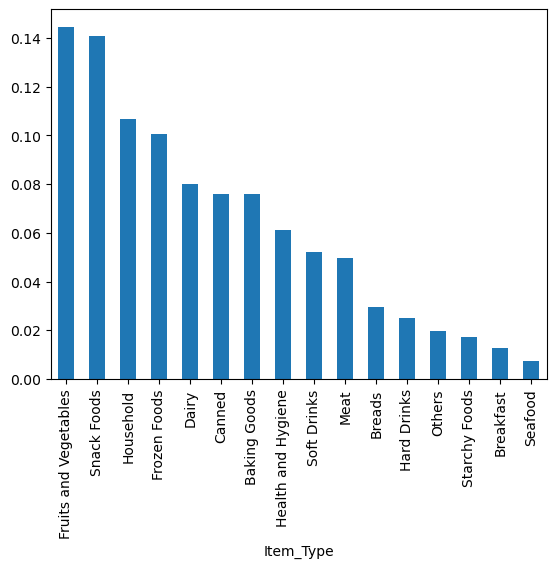

In [14]:
heb_data['Item_Type'].value_counts(normalize=True).plot(kind='bar')
plt.show()

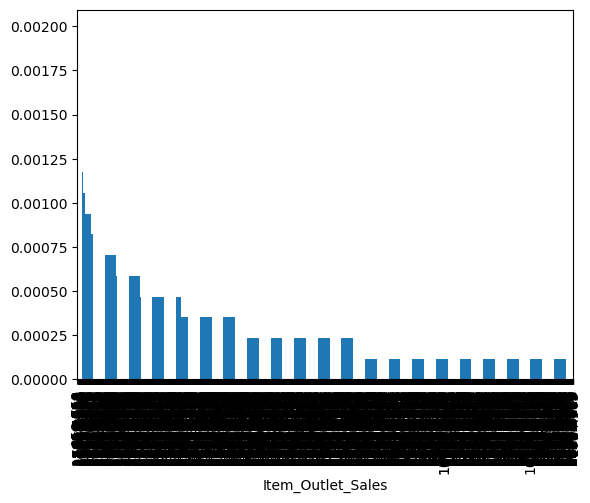

In [8]:
heb_data['Item_Outlet_Sales'].value_counts(normalize=True).plot(kind='bar')
plt.show()

In [19]:
walmart.head()

,url,name,sku,brand,gtin13,description,product_id,availability,currency,price,...,reviews_count,product_details,specifications,5_stars,4_stars,3_stars,2_stars,1_star,uniq_id,scraped_at
0,https://www.walmart.com/ip/Prison-Life-in-the-...,Prison Life in the South (Paperback),717731951,Allen O Abbott,NaN,"<p>At Richmond, and Andersenville during the y...",NaN,OutOfStock,USD,29.95,...,0,NaN,"[{'name': 'Language', 'value': 'English'}, {'n...",0,0,0,0,0,d5c6a458-48ea-5b1e-be3a-e6b626161de5,15/08/2022 20:37:18
1,https://www.walmart.com/ip/Billy-Whiskers-Adve...,Billy Whiskers' Adventures (Paperback),774947758,Frances Trego Montgomery,NaN,"Book Excerpt: ...he,"" said Billy, ""to leave us...",NaN,OutOfStock,USD,10.99,...,0,NaN,"[{'name': 'Language', 'value': 'English'}, {'n...",0,0,0,0,0,26b1ea6c-c9e5-54cd-88d5-d08785817f60,15/08/2022 20:37:19
2,https://www.walmart.com/ip/Champion-Spark-Plug...,Champion Spark Plug 888 Spark Plug,430881880,Champion,3.755115e+10,0,NaN,OutOfStock,USD,2.43,...,0,NaN,"[{'name': 'Brand', 'value': 'Champion'}, {'nam...",0,0,0,0,0,482a2e7f-8289-56ea-87e8-2d4ec01e0363,15/08/2022 20:37:24
3,https://www.walmart.com/ip/Mainstays-5x7-Multi...,Mainstays 5x7 Multi Medallion Rug,1244525562,Mainstays,1.942160e+11,Easily create your own tropical oasis by addin...,NaN,OutOfStock,USD,39.94,...,0,NaN,"[{'name': 'Country of Origin - Textiles', 'val...",0,0,0,0,0,7ddd5e26-b7cb-5194-9edb-5d64505e9b34,15/08/2022 20:37:28
4,https://www.walmart.com/ip/The-History-of-Engl...,"The History of England, from the First Invasio...",658708591,John Lingard,NaN,This work has been selected by scholars as bei...,NaN,InStock,USD,35.95,...,0,NaN,"[{'name': 'Language', 'value': 'English'}, {'n...",0,0,0,0,0,37902f68-3360-55e9-aa50-1bd525244fb5,15/08/2022 20:37:32


In [20]:
walmart.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   url              10 non-null     object 
 1   name             10 non-null     object 
 2   sku              10 non-null     int64  
 3   brand            10 non-null     object 
 4   gtin13           4 non-null      float64
 5   description      10 non-null     object 
 6   product_id       0 non-null      float64
 7   availability     10 non-null     object 
 8   currency         10 non-null     object 
 9   price            10 non-null     float64
 10  images           10 non-null     object 
 11  avg_rating       1 non-null      float64
 12  reviews_count    10 non-null     int64  
 13  product_details  0 non-null      float64
 14  specifications   10 non-null     object 
 15  5_stars          10 non-null     int64  
 16  4_stars          10 non-null     int64  
 17  3_stars          10

In [25]:
g_data.head()

,Product_ID,Product_Name,Catagory,Supplier_ID,Supplier_Name,Stock_Quantity,Reorder_Level,Reorder_Quantity,Unit_Price,Date_Received,Last_Order_Date,Expiration_Date,Warehouse_Location,Sales_Volume,Inventory_Turnover_Rate,Status
0,29-205-1132,Sushi Rice,Grains & Pulses,38-037-1699,Jaxnation,22,72,70,$4.50,8/16/2024,6/29/2024,9/19/2024,48 Del Sol Trail,32,19,Discontinued
1,40-681-9981,Arabica Coffee,Beverages,54-470-2479,Feedmix,45,77,2,$20.00,11/1/2024,5/29/2024,5/8/2024,36 3rd Place,85,1,Discontinued
2,06-955-3428,Black Rice,Grains & Pulses,54-031-2945,Vinder,30,38,83,$6.00,8/3/2024,6/10/2024,9/22/2024,3296 Walton Court,31,34,Backordered
3,71-594-6552,Long Grain Rice,Grains & Pulses,63-492-7603,Brightbean,12,59,62,$1.50,12/8/2024,2/19/2025,4/17/2024,3 Westerfield Crossing,95,99,Active
4,57-437-1828,Plum,Fruits & Vegetables,54-226-4308,Topicstorm,37,30,74,$4.00,7/3/2024,10/11/2024,10/5/2024,15068 Scoville Court,62,25,Backordered


In [26]:
g_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 990 entries, 0 to 989
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Product_ID               990 non-null    object
 1   Product_Name             990 non-null    object
 2   Catagory                 989 non-null    object
 3   Supplier_ID              990 non-null    object
 4   Supplier_Name            990 non-null    object
 5   Stock_Quantity           990 non-null    int64 
 6   Reorder_Level            990 non-null    int64 
 7   Reorder_Quantity         990 non-null    int64 
 8   Unit_Price               990 non-null    object
 9   Date_Received            990 non-null    object
 10  Last_Order_Date          990 non-null    object
 11  Expiration_Date          990 non-null    object
 12  Warehouse_Location       990 non-null    object
 13  Sales_Volume             990 non-null    int64 
 14  Inventory_Turnover_Rate  990 non-null    i

In [11]:
import pandas as pd

# Walmart 
walmart_data = pd.DataFrame({
    'item': ['Milk', 'Eggs', 'Bread', 'Rice'],
    'unit_price': [2.50, 2.58, 1.99, 3.50],
    'unit_size': ['1 gal', '12 ct', '1 loaf', '1 lb'],
    'store': ['Walmart'] * 4
})
heb_data = pd.DataFrame({
    'item': ['Milk', 'Eggs', 'Bread', 'Rice'],
    'unit_price': [2.75, 2.52, 2.10, 3.25],
    'unit_size': ['1 gal', '12 ct', '1 loaf', '1 lb'],
    'store': ['HEB'] * 4
})

In [12]:
 #Merge datasets
combined = pd.concat([walmart_data, heb_data], ignore_index=True)
# compare prices side-by-side
pivoted = combined.pivot_table(index='item', columns='store', values='unit_price').reset_index()
# which store is cheaper
pivoted['cheaper_store'] = pivoted.apply(
    lambda row: 'Walmart' if row['Walmart'] < row['HEB'] else 'HEB', axis=1
)


In [13]:
# Feature engineering: price difference
pivoted['price_diff'] = pivoted['Walmart'] - pivoted['HEB']

# Features and target
X = pivoted[['Walmart', 'HEB', 'price_diff']]
y = pivoted['cheaper_store']

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train model
model = RandomForestClassifier()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.0


In [24]:
total_cost_option1 = '15.99'
total_cost_option2 = '17.50'

float_cost_option1 = float(total_cost_option1)
float_cost_option2 = float(total_cost_option2)


if float_cost_option1 < float_cost_option2:
    print(f"Option 1 is cheaper: ${float_cost_option1:.2f} vs ${float_cost_option2:.2f}")
    print(f"You save ${float_cost_option2 - float_cost_option1:.2f} with Option 1")
elif float_cost_option2 < float_cost_option1:
    print(f"Option 2 is cheaper: ${float_cost_option2:.2f} vs ${float_cost_option1:.2f}")
    print(f"You save ${float_cost_option1 - float_cost_option2:.2f} with Option 2")
else:
    print(f"Both options cost the same: ${float_cost_option1:.2f}")

plt.show()

# You could also visualize the comparison with matplotlib or seaborn
# if you want a graphical representation


Option 1 is cheaper: $15.99 vs $17.50
You save $1.51 with Option 1


In [21]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Example pivoted dataset
pivoted = pd.DataFrame({
    'item': ['Bread','Eggs','Milk','Rice'],
    'Walmart': [1.99, 2.58, 2.50, 3.50],
    'HEB': [2.10, 2.52, 2.75, 3.25],
    'cheaper_store': ['Walmart','HEB','Walmart','HEB']
})

# Feature engineering: price difference
pivoted['price_diff'] = pivoted['Walmart'] - pivoted['HEB']

# Features and target
X = pivoted[['Walmart','HEB','price_diff']]
y = pivoted['cheaper_store']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# KNN model (try k=3 neighbors)
knn = KNeighborsClassifier(n_neighbors=2)
knn.fit(X_train, y_train)

# Predict
y_pred = knn.predict(X_test)

# Evaluate
print("Predictions:", y_pred)
print("Accuracy:", accuracy_score(y_test, y_pred))

Predictions: ['Walmart']
Accuracy: 0.0


In [22]:
import pandas as pd
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import LeaveOneOut, cross_val_score

# pivoted dataset - 
pivoted = pd.DataFrame({
    'item': ['Bread', 'Eggs', 'Milk', 'Rice', 'Cereal', 'Cheese', 'Chicken', 'Apples'],
    'Walmart': [1.99, 2.58, 2.50, 3.50, 3.99, 4.25, 5.99, 2.99],
    'HEB': [2.10, 2.52, 2.75, 3.25, 4.15, 3.99, 6.25, 3.15],
    'cheaper_store': ['Walmart', 'HEB', 'Walmart', 'HEB', 'Walmart', 'HEB', 'Walmart', 'Walmart']
})

# Feature engineering: more meaningful features
pivoted['price_diff'] = pivoted['Walmart'] - pivoted['HEB']
pivoted['price_ratio'] = pivoted['Walmart'] / pivoted['HEB']
pivoted['avg_price'] = (pivoted['Walmart'] + pivoted['HEB']) / 2

# Features and target - select most relevant features
X = pivoted[['price_diff', 'price_ratio']]  # Simplified feature set
y = pivoted['cheaper_store']

# Use Leave-One-Out cross-validation instead of a single train/test split
# This is better for very small datasets
loo = LeaveOneOut()
knn = KNeighborsClassifier(n_neighbors=1)  # Use k=1 for very small datasets

# Evaluate with cross-validation
cv_scores = cross_val_score(knn, X, y, cv=loo)
print(f"Cross-validation accuracy: {np.mean(cv_scores):.2f}")

# Train on full dataset for final model
knn.fit(X, y)

# Example of making a prediction for a new item
new_item = pd.DataFrame({
    'price_diff': [0.2],  # Walmart - HEB
    'price_ratio': [1.05]  # Walmart / HEB
})

prediction = knn.predict(new_item)
print(f"Predicted cheaper store for new item: {prediction[0]}")

Cross-validation accuracy: 0.88
Predicted cheaper store for new item: HEB


In [1]:
import pandas as pd

#  pivoted dataset
pivoted = pd.DataFrame({
    'item': ['Bread', 'Eggs', 'Milk', 'Rice', 'Cereal', 'Cheese', 'Chicken', 'Apples'],
    'Walmart': [1.99, 2.58, 2.50, 3.50, 3.99, 4.25, 5.99, 2.99],
    'HEB': [2.10, 2.52, 2.75, 3.25, 4.15, 3.99, 6.25, 3.15],
})

# Create a column that shows where each item is cheaper
pivoted['cheaper_store'] = pivoted.apply(
    lambda row: 'Walmart' if row['Walmart'] < row['HEB'] else 'HEB', 
    axis=1
)

# Calculate price difference (positive means HEB is cheaper)
pivoted['price_diff'] = pivoted['HEB'] - pivoted['Walmart']

# Display the results
print("Items cheaper at Walmart:")
walmart_cheaper = pivoted[pivoted['cheaper_store'] == 'Walmart']
print(walmart_cheaper[['item', 'Walmart', 'HEB', 'price_diff']])

print("\nItems cheaper at HEB:")
heb_cheaper = pivoted[pivoted['cheaper_store'] == 'HEB']
print(heb_cheaper[['item', 'Walmart', 'HEB', 'price_diff']])

# Calculate savings by shopping at the cheaper store for each item
pivoted['savings'] = abs(pivoted['Walmart'] - pivoted['HEB'])
total_savings = pivoted['savings'].sum()

print(f"\nTotal potential savings by choosing the cheaper store: ${total_savings:.2f}")

# Optional: Sort by highest savings
print("\nItems ranked by potential savings:")
print(pivoted.sort_values('savings', ascending=False)[['item', 'Walmart', 'HEB', 'cheaper_store', 'savings']])

Items cheaper at Walmart:
      item  Walmart   HEB  price_diff
0    Bread     1.99  2.10        0.11
2     Milk     2.50  2.75        0.25
4   Cereal     3.99  4.15        0.16
6  Chicken     5.99  6.25        0.26
7   Apples     2.99  3.15        0.16

Items cheaper at HEB:
     item  Walmart   HEB  price_diff
1    Eggs     2.58  2.52       -0.06
3    Rice     3.50  3.25       -0.25
5  Cheese     4.25  3.99       -0.26

Total potential savings by choosing the cheaper store: $1.51

Items ranked by potential savings:
      item  Walmart   HEB cheaper_store  savings
5   Cheese     4.25  3.99           HEB     0.26
6  Chicken     5.99  6.25       Walmart     0.26
2     Milk     2.50  2.75       Walmart     0.25
3     Rice     3.50  3.25           HEB     0.25
4   Cereal     3.99  4.15       Walmart     0.16
7   Apples     2.99  3.15       Walmart     0.16
0    Bread     1.99  2.10       Walmart     0.11
1     Eggs     2.58  2.52           HEB     0.06


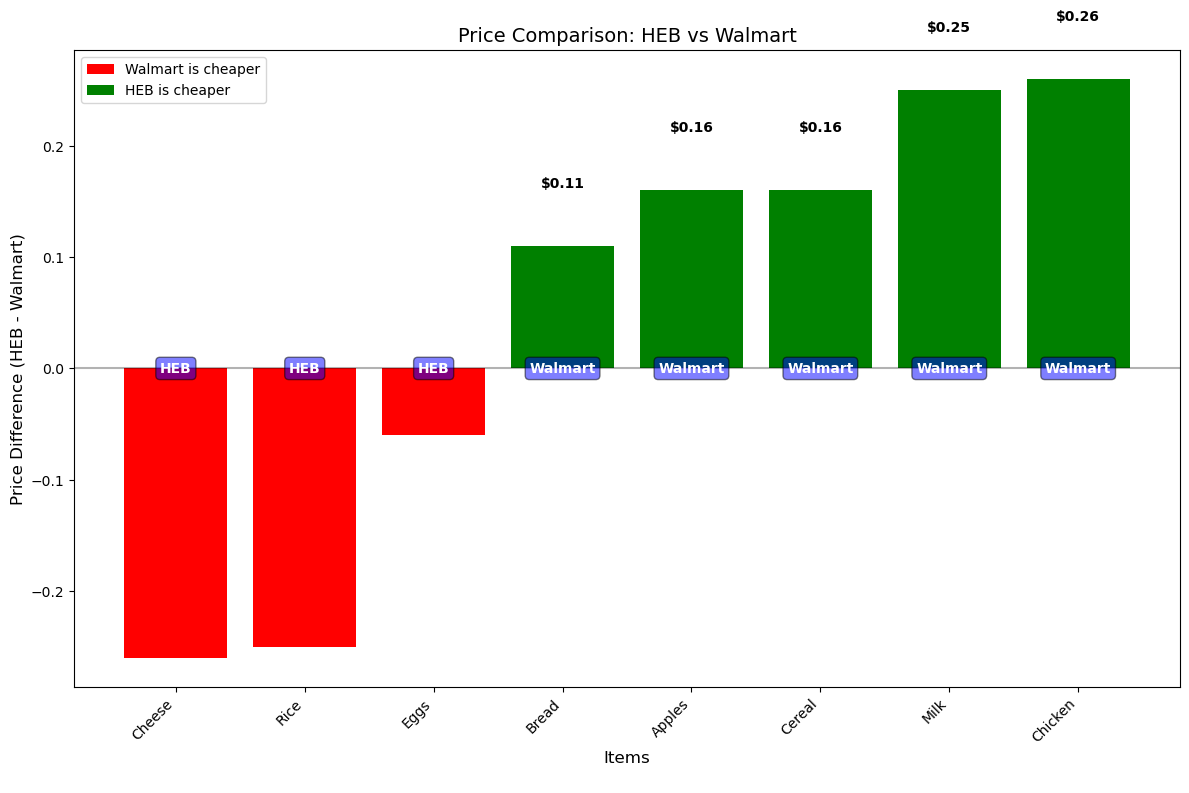

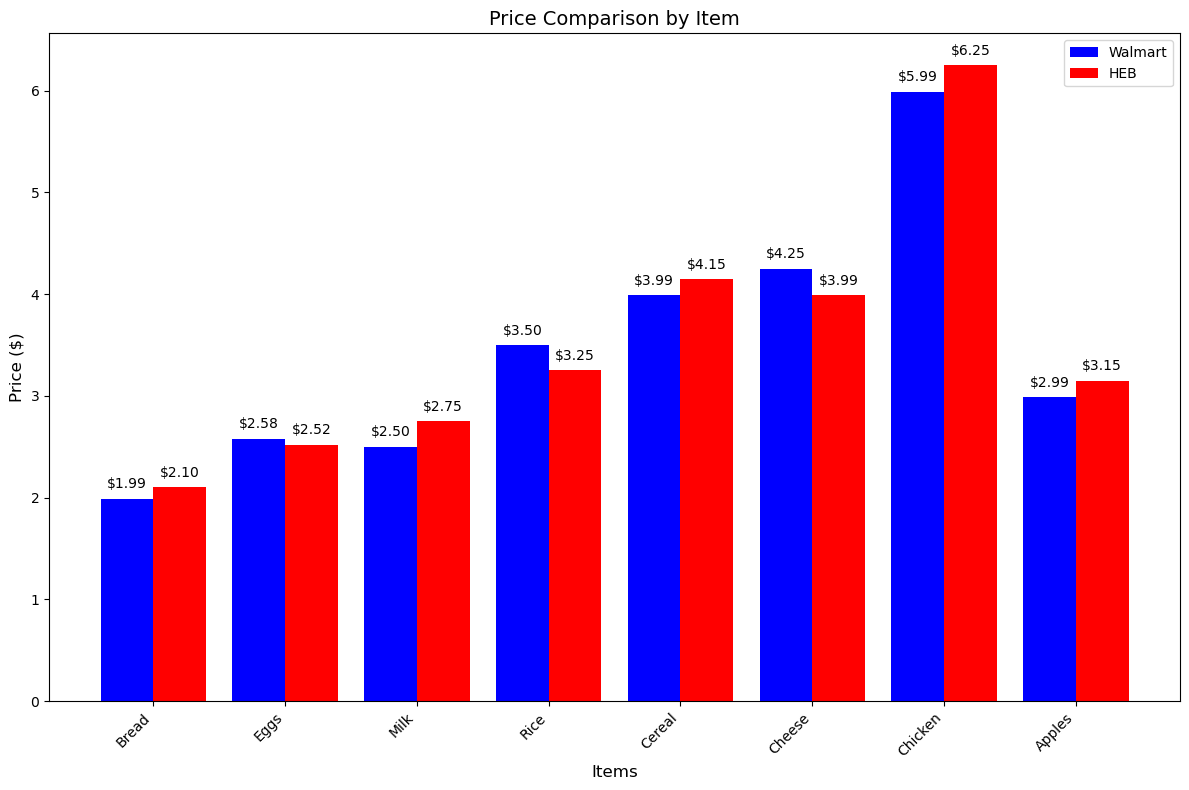

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Example pivoted dataset
pivoted = pd.DataFrame({
    'item': ['Bread', 'Eggs', 'Milk', 'Rice', 'Cereal', 'Cheese', 'Chicken', 'Apples'],
    'Walmart': [1.99, 2.58, 2.50, 3.50, 3.99, 4.25, 5.99, 2.99],
    'HEB': [2.10, 2.52, 2.75, 3.25, 4.15, 3.99, 6.25, 3.15],
})

# Create a column that shows where each item is cheaper
pivoted['cheaper_store'] = pivoted.apply(
    lambda row: 'Walmart' if row['Walmart'] < row['HEB'] else 'HEB', 
    axis=1
)

# Calculate price difference (negative means Walmart is cheaper)
pivoted['price_diff'] = pivoted['HEB'] - pivoted['Walmart']

# Sort by price difference for better visualization
pivoted_sorted = pivoted.sort_values('price_diff')

# Set up the plot
plt.figure(figsize=(12, 8))

# Create a bar chart showing price differences
bars = plt.bar(
    pivoted_sorted['item'], 
    pivoted_sorted['price_diff'],
    color=[('red' if diff < 0 else 'green') for diff in pivoted_sorted['price_diff']]
)

# Add labels and title
plt.xlabel('Items', fontsize=12)
plt.ylabel('Price Difference (HEB - Walmart)', fontsize=12)
plt.title('Price Comparison: HEB vs Walmart', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)

# Add a legend
red_patch = plt.Rectangle((0,0),1,1,fc="red")
green_patch = plt.Rectangle((0,0),1,1,fc="green")
plt.legend([red_patch, green_patch], ['Walmart is cheaper', 'HEB is cheaper'])

# Add price difference labels on top of each bar
for bar in bars:
    height = bar.get_height()
    if height < 0:
        plt.text(
            bar.get_x() + bar.get_width()/2.,
            height - 0.1,
            f'${abs(height):.2f}',
            ha='center', va='top', color='white', fontweight='bold'
        )
    else:
        plt.text(
            bar.get_x() + bar.get_width()/2.,
            height + 0.05,
            f'${height:.2f}',
            ha='center', va='bottom', fontweight='bold'
        )

# Add store logos or names on the bars
for i, (_, row) in enumerate(pivoted_sorted.iterrows()):
    store = row['cheaper_store']
    plt.text(
        i, 
        0, 
        store,
        ha='center', 
        va='center',
        fontweight='bold',
        color='white',
        bbox=dict(facecolor='blue', alpha=0.5, boxstyle='round,pad=0.3')
    )

plt.tight_layout()
plt.show()

# Optional: Create a grouped bar chart to compare actual prices
plt.figure(figsize=(12, 8))

# Set width of bars
barWidth = 0.4

# Set positions of the bars on X axis
r1 = range(len(pivoted))
r2 = [x + barWidth for x in r1]

# Create grouped bars
plt.bar(r1, pivoted['Walmart'], width=barWidth, label='Walmart', color='blue')
plt.bar(r2, pivoted['HEB'], width=barWidth, label='HEB', color='red')

# Add labels and title
plt.xlabel('Items', fontsize=12)
plt.ylabel('Price ($)', fontsize=12)
plt.title('Price Comparison by Item', fontsize=14)
plt.xticks([r + barWidth/2 for r in range(len(pivoted))], pivoted['item'], rotation=45, ha='right')
plt.legend()

# Add price labels on top of each bar
for i, price in enumerate(pivoted['Walmart']):
    plt.text(i, price + 0.1, f'${price:.2f}', ha='center')
    
for i, price in enumerate(pivoted['HEB']):
    plt.text(i + barWidth, price + 0.1, f'${price:.2f}', ha='center')

plt.tight_layout()
plt.show()